# KMeans Optimization for Nods Classification in Spectroscopic Data Reduction

In [35]:
import numpy as np
from astropy.io import fits
import os
import shutil
import matplotlib.pyplot as plt
import glob
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score, precision_score, recall_score

### Building functions to run with multiple datasets

In [36]:
def classify_AB_frames(frames):
    collapsed = []
    center = []
    width = []
    total_flux = []
    peak = []
    asymmetry = []
    
    # feature engineering!
    for j, frame in enumerate(frames):
        spec = np.nanmedian(frame, axis=0) # collapsed frame
        collapsed.append(spec)
    
        spatial_profile = np.nanmedian(frame, axis=1) # collapsed spatial profile
        x = np.arange(len(spatial_profile))
        denom = np.nansum(spatial_profile)
        
        if not np.isfinite(denom) or (denom == 0):  # avoiding errors with undefined denominators when computing centroid
            print(f"Bad spatial profile in frame {j}, denom = {denom}")
            center.append(np.nan)
            width.append(np.nan)
            total_flux.append(np.nan)
            peak.append(np.nan)
            asymmetry.append(np.nan)
    
        else:
            cen = np.nansum(x * spatial_profile) / denom   # calculating the flux-weighted centroid
            
            wid = np.sqrt(np.nansum(spatial_profile * (x - cen)**2) / denom)  # calculating the general width of each frame
            
            pk = np.nanargmax(spatial_profile)  # finding the overall greatest peak of each frame
            
            # asymmetry calculations---toward left or right of avg. per frame
            mid = len(spatial_profile) // 2  # to do some rounding
            left_flux = np.nansum(spatial_profile[:mid])
            right_flux = np.nansum(spatial_profile[mid:])
            asym = (right_flux - left_flux) / (right_flux + left_flux + 1e-8) # so it never blows up, because it did.
    
            center.append(cen)
            width.append(wid)
            total_flux.append(denom)
            peak.append(pk)
            asymmetry.append(asym)
    
    A_spectra = []
    B_spectra = []
    AB_labels = []
    nods_num_labels = []
    
    # working in groups of 8 frames per classification to "follow" classic patterns but allow wiggle room
    for start in range(0, len(collapsed), 8): 
        end = min(start + 8, len(collapsed))
    
        group_spectra = collapsed[start:end]
        group_centers = np.array(center[start:end], dtype=float)
        group_peaks = np.array(peak[start:end], dtype=float)
        group_asym = np.array(asymmetry[start:end], dtype=float)
        group_widths = np.array(width[start:end], dtype=float)
        group_flux = np.array(total_flux[start:end], dtype=float)
        
        features = np.column_stack([group_centers, group_widths, group_peaks, group_asym, group_flux])

        # standardize features by scaling to unit variance, putting features on a more comparable scale
        scaler = StandardScaler()
        features = scaler.fit_transform(features)

        features[:, 0] *= 3.0  # weighting centroid feature more by multiplying each value by three, an overall 9x more influence
    
        # again, confirming we don't have bad frames (Kmeans won't take NaNs)
        if not np.all(np.isfinite(features)):
            print(f"Non-finite features in group {start}:{end}") 
            print(features)
            continue
    
        kmeans = KMeans(n_clusters=2, random_state=0, n_init=20).fit(features) # run clustering algorithm!
        labels = kmeans.labels_
    
        # to visualize values
        print(f"group {start}:{end}")
        print("raw centers: ", group_centers)
        print("raw peaks: ", group_peaks)
        print("raw asymmetry: ", group_asym)
        print("raw widths: ", group_widths)
        print("total flux: ", group_flux) 
        print("counts: ", [np.sum(labels == j) for j in range(2)])
    
        # breaking up clusters to groups A and B
        cluster_center_means = []
        for j in range(2):
            cluster_center_means.append(np.nanmean(group_centers[labels == j]))
        cluster_center_means = np.array(cluster_center_means)
    
        # assigning letter classification to numerical value
        label_A = np.argmin(cluster_center_means)   # A = 0
        label_B = np.argmax(cluster_center_means)   # B = 1
    
        print("cluster mean centers: ", cluster_center_means)
        print("label_A: ", label_A, "label_B: ", label_B)
    
        # more silly group organization
        for i, label in enumerate(labels):
            if label == label_A:
                A_spectra.append(group_spectra[i])
            else:
                B_spectra.append(group_spectra[i])
    
        # for plotting/pipeline purposes (these are inefficient but I didn't want to modify prior code)
        # can neglect everything below
        group_labels_AB = ['A' if l == label_A else 'B' for l in labels]
        AB_labels.extend(group_labels_AB)
        group_labels_num = [0 if l == label_A else 1 for l in labels]
        nods_num_labels.extend(group_labels_num)

    # mostly just outputs from here on out
    print("num A:", len(A_spectra))
    print("num B:", len(B_spectra))

    for j, (c, w, f, lab) in enumerate(zip(center, width, total_flux, AB_labels)):
        print(j, c, w, f, lab)
    
    A_frames, B_frames = [], []
    for frame, label in zip(frames, AB_labels):
        if label == 'A':
            A_frames.append(frame)
        else:
            B_frames.append(frame)
    
    return A_frames, B_frames, A_spectra, B_spectra, AB_labels, nods_num_labels, collapsed, center, peak, asymmetry, total_flux, width

## Run data for Testing Set Tau Boo!

### Benchmark

In [72]:
# Run once, this takes a bit to go over all frames

frames = []
filenames = []

# opening frames for Tau Boo target star
for i in range(129, 187):   # adjust for different data sets
    file = f"../../research/Test_Data/2017jun18/TauBoo/jun18s0{i}.fits"
    with fits.open(file) as hdul:
        filenames.append(file)
        frames.append(hdul[0].data.astype(float))

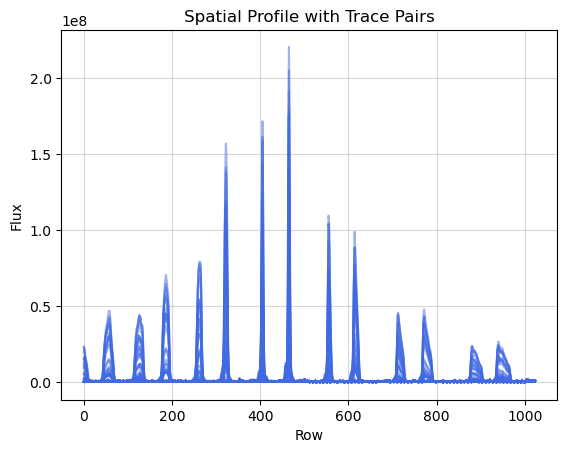

In [73]:
collapsed = []
center = []

plt.figure()

for frame in frames:
    spec = np.sum(frame, axis=0) # collapsed spectrum frame
    collapsed.append(spec)

    spatial_profile = np.sum(frame, axis=1) # collapsed spatial profile
    c = np.sum(np.arange(len(spatial_profile)) * spatial_profile) / np.sum(spatial_profile)  # calculating flux-weighted centroid
    center.append(c)

    plt.plot(spatial_profile, c='royalblue', alpha=0.5)
    #plt.axvline(c, linestyle='--', label=f'centroid = {c:.3f}')
plt.xlabel("Row")
plt.ylabel("Flux")
plt.title("Spatial Profile with Trace Pairs")
plt.grid(alpha=0.5)
plt.show()

Silhouette score: 0.6925070949979809
num A: 46
num B: 12
A max: 476.520500608092
B min: 485.3807719408503
['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'A', 'B', 'A', 'A', 'A', 'B', 'B', 'B']


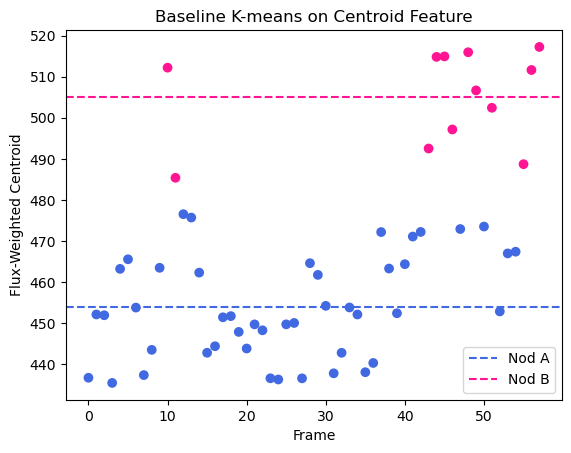

In [74]:
A_spectra = []
B_spectra = []
AB_labels = []
nods_num_labels = []

collapsed = np.array(collapsed)
center = np.array(center)

X = center.reshape(-1,1)

# Baseline model, without any data filtering
N_CLUSTERS = 2  # for A and B!

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0)  # using KMeans from notebook example without adjustments
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

sil = silhouette_score(X, labels)
print("Silhouette score:", sil)

# ORGANIZATION
label_A = np.argmin(centroids)
label_B = np.argmax(centroids)

# A and B labels
group_labels_AB = ['A' if l == label_A else 'B' for l in labels]
AB_labels.extend(group_labels_AB)

print("num A:", np.sum(labels == label_A))
print("num B:", np.sum(labels == label_B))
print("A max:", np.max(center[labels == label_A]))
print("B min:", np.min(center[labels == label_B]))
print(AB_labels)

# Plotting!
colors = ['royalblue' if lab == 0 else 'deeppink' for lab in labels]

plt.scatter(np.arange(len(center)), center, c=colors)
for i in range(N_CLUSTERS):
    color = 'royalblue' if i == 0 else 'deeppink'
    label = 'A' if i == 0 else 'B'
    plt.axhline(centroids[i], linestyle='--', c=color, label=f'Nod {label}')
    plt.xlabel('Frame')
    plt.ylabel('Flux-Weighted Centroid')
    plt.title('Baseline K-means on Centroid Feature')
    plt.legend(loc='lower right')

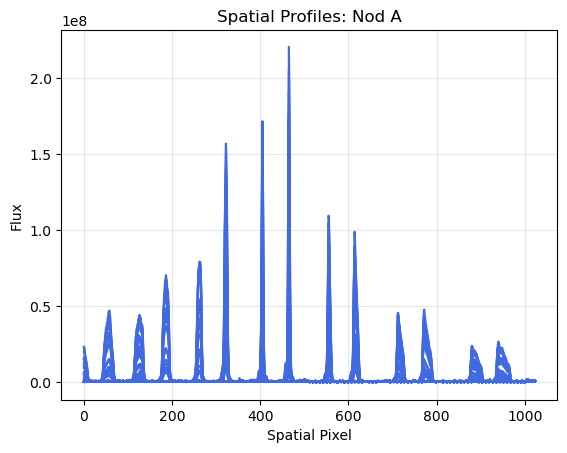

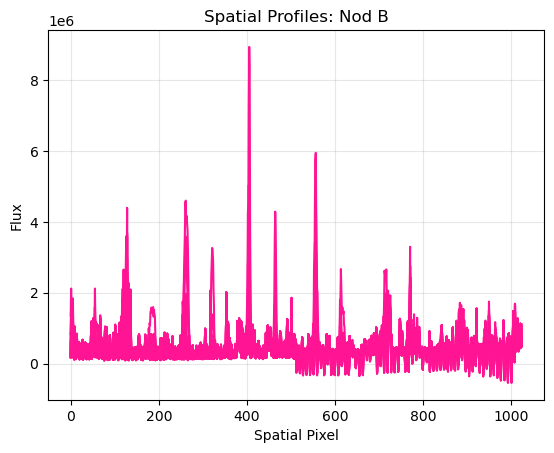

In [77]:
# additional plotting to assess performance visually

for i, label in enumerate(AB_labels):
    if label == 'A':
        spatial_profile = np.sum(frames[i], axis=1)
        plt.plot(spatial_profile, color='royalblue')

plt.title("Spatial Profiles: Nod A")
plt.xlabel("Spatial Pixel")
plt.ylabel("Flux")
plt.grid(alpha=0.3)
plt.show()

for i, label in enumerate(AB_labels):
    if label == 'B':
        spatial_profile = np.sum(frames[i], axis=1)
        plt.plot(spatial_profile, color='deeppink')

plt.title("Spatial Profiles: Nod B")
plt.xlabel("Spatial Pixel")
plt.ylabel("Flux")
plt.grid(alpha=0.3)
plt.show()

### Filtering and real work

In [40]:
bad_frames = []
good_frames = []
good_filenames = []
good_idx = []

# Looking for corrupted frames (low exposure, image is basically flat)
for i, image in enumerate(frames):
    image = image[::-1]

    # to reduce hot pixel impact, finding within a percentile range
    p5 = np.nanpercentile(image, 5)
    p95 = np.nanpercentile(image, 95)
    robust_range = p95 - p5

    if robust_range < 4500:  # hardcoded visually for Tau Boo --- this will be more adaptive within pipeline
        bad_frames.append(filenames[i])
        print("Skipping low-exposure frame:", i, filenames[i])
        continue
    else:
        good_frames.append(image)
        good_filenames.append(filenames[i])
        good_idx.append(i)

print("Good frames:", len(good_frames), good_idx)
print("Bad frames:", len(bad_frames))

frames = good_frames
filenames = good_filenames

Skipping low-exposure frame: 4 ../../research/Test_Data/2017jun18/TauBoo/jun18s0133.fits
Skipping low-exposure frame: 5 ../../research/Test_Data/2017jun18/TauBoo/jun18s0134.fits
Skipping low-exposure frame: 8 ../../research/Test_Data/2017jun18/TauBoo/jun18s0137.fits
Skipping low-exposure frame: 9 ../../research/Test_Data/2017jun18/TauBoo/jun18s0138.fits
Skipping low-exposure frame: 10 ../../research/Test_Data/2017jun18/TauBoo/jun18s0139.fits
Skipping low-exposure frame: 11 ../../research/Test_Data/2017jun18/TauBoo/jun18s0140.fits
Skipping low-exposure frame: 12 ../../research/Test_Data/2017jun18/TauBoo/jun18s0141.fits
Skipping low-exposure frame: 13 ../../research/Test_Data/2017jun18/TauBoo/jun18s0142.fits
Skipping low-exposure frame: 14 ../../research/Test_Data/2017jun18/TauBoo/jun18s0143.fits
Skipping low-exposure frame: 15 ../../research/Test_Data/2017jun18/TauBoo/jun18s0144.fits
Skipping low-exposure frame: 16 ../../research/Test_Data/2017jun18/TauBoo/jun18s0145.fits
Skipping low-e

In [41]:
# run classification!
A_frames, B_frames, A_spectra, B_spectra, AB_labels, nods_num_labels, collapsed, center, peak, asymmetry, total_flux, width = classify_AB_frames(frames)

group 0:8
raw centers:  [582.28370403 590.75232306 592.2766931  586.11274129 582.39812473
 581.27511155 588.57088321 589.90448449]
raw peaks:  [619. 559. 559. 619. 558. 618. 558. 558.]
raw asymmetry:  [0.24573023 0.53561315 0.51962116 0.23126797 0.48648519 0.22456187
 0.51274508 0.54127927]
raw widths:  [202.38620954 195.80070254 198.91143419 204.85068531 205.03965709
 205.449733   197.74910019 193.3551285 ]
total flux:  [1579681.5 2393771.5 2618818.5 1787260.  1020066.  1299078.5 2008638.5
 2567614.5]
counts:  [4, 4]
cluster mean centers:  [583.0174204  590.37609597]
label_A:  0 label_B:  1
group 8:16
raw centers:  [584.44663287 582.8426322  575.84611085 577.08067167 587.06398418
 586.79595158 574.36372341 569.95773924]
raw peaks:  [558. 558. 618. 618. 558. 558. 618. 558.]
raw asymmetry:  [0.50465484 0.49478037 0.22423671 0.22397748 0.50113426 0.51797915
 0.22712136 0.38869171]
raw widths:  [206.00085205 205.55018293 203.41251147 202.42200902 201.14229254
 197.90845922 200.16678313 22

In [42]:
# organize frames and combine for visual purposes (separated due to longer runtime of prior cells)
A_frames = np.array(A_frames, dtype=float)
B_frames = np.array(B_frames, dtype=float)

print("A_frames shape:", A_frames.shape)
print("B_frames shape:", B_frames.shape)

sum_A = np.nanmedian(A_frames, axis=0)   # combined 2D A image
sum_B = np.nanmedian(B_frames, axis=0)   # combined 2D B image

A_frames shape: (10, 1024, 1024)
B_frames shape: (14, 1024, 1024)


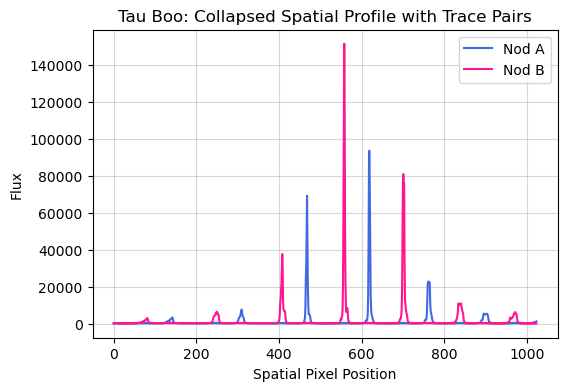

In [81]:
prof_A_1 = np.nanmedian(sum_A, axis=1)  # A spatial profile
prof_B_1 = np.nanmedian(sum_B, axis=1)  # B spatial profile

# plot profiles together for comparison!
plt.figure(figsize=(6,4)) 
plt.plot(prof_A_1, label="Nod A", c="royalblue")
plt.plot(prof_B_1, label="Nod B", c="deeppink")
plt.legend()
plt.title("Tau Boo: Collapsed Spatial Profile with Trace Pairs")
plt.xlabel("Spatial Pixel Position")
plt.ylabel("Flux")
plt.grid(alpha=0.5)
plt.show()

## Metrics and Evaluation

In [82]:
# visually classified nod labels for performance evaluation
A_orig = [0, 3, 7, 23, 24, 27, 31, 32, 35, 36, 52]
B_orig = [1, 2, 6, 17, 18, 21, 22, 25, 26, 30, 33, 34, 53]

# making sure to keep things aligned with dropped frames
# this is all just repetitive organization, had lots of issues with organization within the pipeline
manual_lookup = {}
for i in A_orig:
    manual_lookup[i] = 0

for i in B_orig:
    manual_lookup[i] = 1

manual_labels = []
kept_manual_idx = []

for orig_idx in good_idx:
    if orig_idx in manual_lookup:
        manual_labels.append(manual_lookup[orig_idx])
        kept_manual_idx.append(orig_idx)

manual_labels = np.array(manual_labels)

print("Filtered manual-label indices:", kept_manual_idx)
print("manual_labels:", manual_labels)
print("Number of labeled filtered frames:", len(manual_labels))

labeled_mask = np.array([orig_idx in manual_lookup for orig_idx in good_idx])

print("Labeled mask length:", len(labeled_mask))
print("Number of labeled filtered frames:", np.sum(labeled_mask))

Filtered manual-label indices: [0, 1, 2, 3, 6, 7, 17, 18, 21, 22, 23, 24, 25, 26, 27, 30, 31, 32, 33, 34, 35, 36, 52, 53]
manual_labels: [0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 1]
Number of labeled filtered frames: 24
Labeled mask length: 24
Number of labeled filtered frames: 24


In [83]:
# function pulled from HW 3
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues, ax=None):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.

    Inputs
    cm: confusion matrix (2D numpy array)
    classes: list of class labels
    normalize: whether to normalize the matrix
    title: title of the plot
    cmap: color map for the plot
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        
    # adjusted to merge figures together if wanted!    
    if ax is None:
        fig, ax = plt.subplots()
    
    print(cm)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", verticalalignment="center",
                 color="green" if i == j else "red", fontsize = 30)

    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    
    return im

In [86]:
# metrics! with or without labels to compare, since we only have them if done manually
# also confusion matrix for comparison

def evaluate_clustering(X, true_labels=None, plot_cm=False, ax=None):
    # runs KMeans clustering
    kmeans = KMeans(n_clusters=2, n_init=20, random_state=0)
    pred = kmeans.fit_predict(X)

    results = {}

    # Unsupervised clustering metric to see how well the clusters are separated
    if len(np.unique(pred)) > 1:  # if we have two clusters, do it
        results["silhouette"] = silhouette_score(X, pred)
    else:
        results["silhouette"] = np.nan

    # if we have labels for comparison (supervised method), calculate accuracy, precision, recall
    if true_labels is not None:
        # trying both label assignments
        acc1 = accuracy_score(true_labels, pred)
        acc2 = accuracy_score(true_labels, 1 - pred)

        if acc2 > acc1:
            pred = 1 - pred

        # compute all metrics!
        results["accuracy"] = accuracy_score(true_labels, pred)
        results["precision"] = precision_score(true_labels, pred)
        results["recall"] = recall_score(true_labels, pred)

        # confusion matrix
        cm = confusion_matrix(true_labels, pred)
        results["confusion_matrix"] = cm
        if plot_cm:
            plot_confusion_matrix(cm, ["Nod A", "Nod B"], normalize=True, ax=ax, title=f"Confusion Matrix: {feats}")

    return results

ValueError: operands could not be broadcast together with shapes (58,) (24,) 

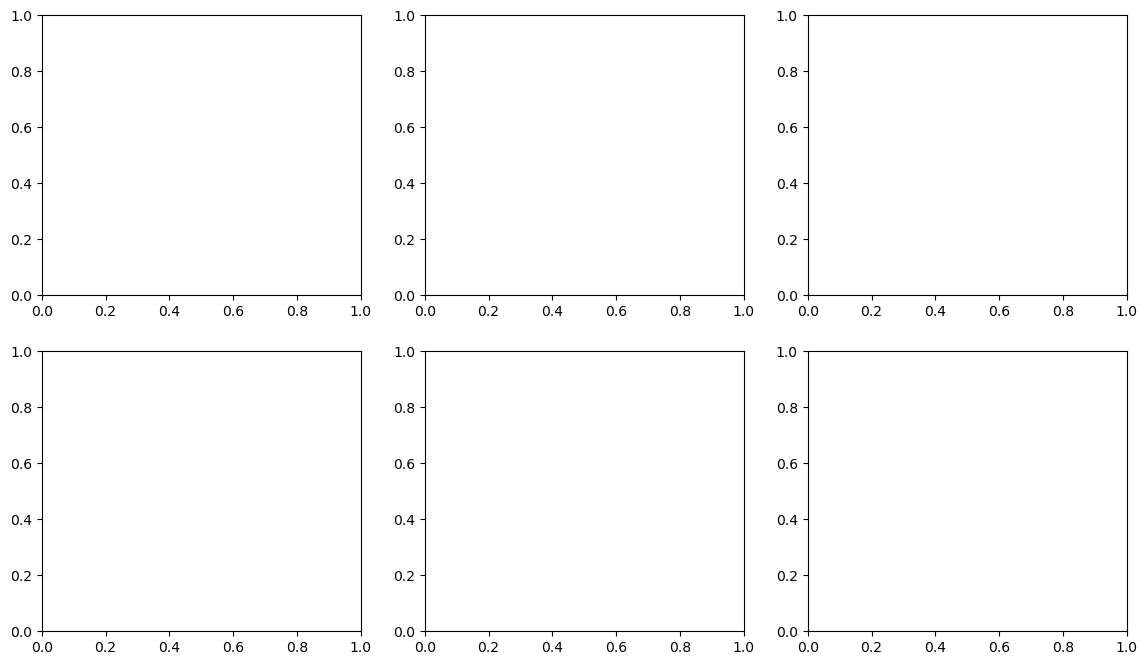

In [87]:
# evaluate with different configurations
feature_dict = {"center": np.array(center), "width": np.array(width), "flux": np.array(total_flux), "peak": np.array(peak), "asym": np.array(asymmetry)}
feature_sets = [["center"], ["center", "width"], ["center", "flux"], ["center", "peak"], ["center", "asym"], ["center", "peak", "asym"]]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

results = []
for i, feats in enumerate(feature_sets):
    cols = []
    
    for feat in feats:
        cols.append(feature_dict[feat])
        
    X = np.column_stack(cols)
    
    # keep only rows with finite values and manual labels
    finite_mask = np.all(np.isfinite(X), axis=1)
    mask = finite_mask & labeled_mask

    X_use = X[mask]
    y_use = np.array([manual_lookup[idx] for idx in np.array(good_idx)[mask]])

    # calculate metrics
    metrics = evaluate_clustering(X_use, y_use, plot_cm=True, ax=axes[i])

    row = {"features": feats, **metrics}
    results.append(row)
    
plt.subplots_adjust(hspace=0.6)
plt.show()

for r in results:
    print(r)

# Trying on testing set - 51Peg

In [88]:
# get frames

frames = []
filenames = []

for i in range(239, 282):
    file = f"../../research/Test_Data/2017sep07/51Peg/sep07s0{i}.fits"
    with fits.open(file) as hdul:
        filenames.append(file)
        frames.append(hdul[0].data.astype(float))

print("Number of raw frames:", len(frames))
print("Frame shape:", frames[0].shape)

Number of raw frames: 43
Frame shape: (1024, 1024)


In [90]:
# repeating same steps from Tau Boo training set with testing set 51 Peg

bad_frames = []
good_frames = []
good_filenames = []
good_idx = []

for i, image in enumerate(frames):
    test_image = image[::-1]

    p5 = np.nanpercentile(test_image, 5)
    p95 = np.nanpercentile(test_image, 95)
    robust_range = p95 - p5
    print(robust_range)

    if robust_range < 3100: # hardcoded this again, can optimize later
        bad_frames.append(filenames[i])
        print("Skipping low-exposure frame:", i, filenames[i])
    else:
        good_frames.append(image)
        good_filenames.append(filenames[i])
        good_idx.append(i)

frames = good_frames
filenames = good_filenames

print("Good frames:", len(frames), good_idx)
print("Bad frames:", len(bad_frames))

3260.0
5155.0
5020.0
3274.0
3357.0
4688.0
5096.0
3181.0
3708.0
5129.0
6464.25
4107.25
4381.0
5890.0
6637.5
3675.0
3371.0
4816.0
5750.0
3880.0
3967.0
5294.0
5240.0
3751.0
4100.0
4765.0
5206.0
4089.0
4127.25
4911.0
5199.0
4371.0
4365.0
4898.25
5242.0
4059.0
4207.0
5099.25
5193.25
4195.0
4417.0
5063.0
5124.0
Good frames: 43 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
Bad frames: 0


In [91]:
# run classification!
A_frames, B_frames, A_spectra, B_spectra, AB_labels, nods_num_labels, collapsed, center, peak, asymmetry, total_flux, width = classify_AB_frames(frames)

group 0:8
raw centers:  [486.75102099 460.87239104 462.5155457  486.92759457 486.9763825
 463.59899486 460.7310273  483.63979736]
raw peaks:  [406. 466. 466. 406. 406. 466. 466. 406.]
raw asymmetry:  [-0.1395565  -0.47743713 -0.49226486 -0.14017401 -0.12472418 -0.4825101
 -0.50008699 -0.16449593]
raw widths:  [242.58082087 211.55030783 209.35576057 243.25558091 245.20582146
 212.41168    208.68210736 243.27723316]
total flux:  [1014087.5 1696460.  1763510.   984829.5  968032.  1579683.  1767361.5
  962616.5]
counts:  [4, 4]
cluster mean centers:  [486.07369886 461.92948972]
label_A:  1 label_B:  0
group 8:16
raw centers:  [475.05518412 463.26946129 455.23269687 471.99656708 470.60704403
 460.80198262 456.94585086 479.60109281]
raw peaks:  [406. 466. 466. 406. 406. 466. 466. 406.]
raw asymmetry:  [-0.18565192 -0.4469806  -0.48028463 -0.18901122 -0.17676509 -0.45360159
 -0.45599829 -0.14909139]
raw widths:  [231.06567677 218.30235268 210.32929233 226.14220966 222.92031499
 216.10738162 2

In [92]:
# organize frames and combine for visual purposes (separated due to longer runtime of prior cells)
A_frames = np.array(A_frames, dtype=float)
B_frames = np.array(B_frames, dtype=float)

print("A_frames shape:", A_frames.shape)
print("B_frames shape:", B_frames.shape)

sum_A = np.nanmedian(A_frames, axis=0)   # combined 2D A image
sum_B = np.nanmedian(B_frames, axis=0)   # combined 2D B image

A_frames shape: (20, 1024, 1024)
B_frames shape: (23, 1024, 1024)


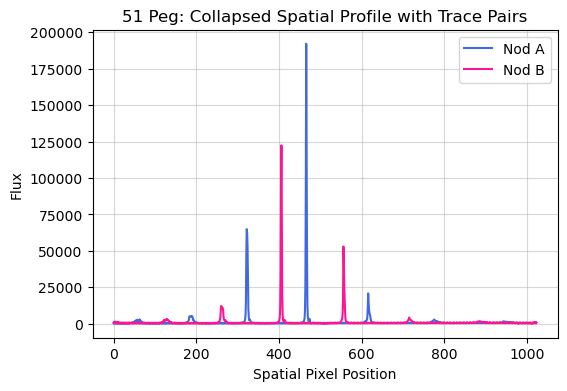

In [93]:
prof_A_1 = np.nanmedian(sum_A, axis=1)  # A spatial profile
prof_B_1 = np.nanmedian(sum_B, axis=1)  # B spatial profile

# plot profiles together for comparison!
plt.figure(figsize=(6,4)) 
plt.plot(prof_A_1, label="Nod A", c="royalblue")
plt.plot(prof_B_1, label="Nod B", c="deeppink")
plt.legend()
plt.title("51 Peg: Collapsed Spatial Profile with Trace Pairs")
plt.xlabel("Spatial Pixel Position")
plt.ylabel("Flux")
plt.grid(alpha=0.5)
plt.show()

In [132]:
# evaluate with different configurations
feature_dict = {"center": np.array(center), "width": np.array(width), "flux": np.array(total_flux), "peak": np.array(peak), "asym": np.array(asymmetry)}
feature_sets = [["center"], ["center", "width"], ["center", "flux"], ["center", "peak"], ["center", "asym"], ["center", "peak", "asym"]]

results = []
for feats in feature_sets:
    cols = []
    
    for feat in feats:
        cols.append(feature_dict[feat])
        
    X = np.column_stack(cols)
    
    # keep only rows with finite values, not worrying about manual labels
    finite_mask = np.all(np.isfinite(X), axis=1)
    X_use = X[finite_mask]

    # calculate metrics
    metrics = evaluate_clustering(X_use, true_labels=None, plot_cm=False)

    row = {"features": feats, **metrics}
    results.append(row)

for r in results:
    print(r)

{'features': ['center'], 'silhouette': 0.6266863690823119}
{'features': ['center', 'width'], 'silhouette': 0.5936037018860576}
{'features': ['center', 'flux'], 'silhouette': 0.5799365065970502}
{'features': ['center', 'peak'], 'silhouette': 0.9097841834175101}
{'features': ['center', 'asym'], 'silhouette': 0.6265470440368663}
{'features': ['center', 'peak', 'asym'], 'silhouette': 0.9097794341352626}
